In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu118 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 2.0 MB/s eta 0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 78.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 41.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 103.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 31.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 13.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 6.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━

Device : cuda
PyTorch: 2.3.1+cu118
Total available train samples: 56788
Train: 4000 | Val: 1000

  Model  : H2Former
  Params : 60.48M
  Device : cuda
  Ep 001 | Loss:0.5711 | Dice:0.6590 | IoU:0.4964 | PixAcc:0.9724 | Acc:0.9724 | Prec:0.5257 | Rec:0.8966 | Spec:0.9747
  Ep 010 | Loss:0.1560 | Dice:0.8158 | IoU:0.6921 | PixAcc:0.9888 | Acc:0.9888 | Prec:0.7963 | Rec:0.8407 | Spec:0.9934
  Ep 020 | Loss:0.1284 | Dice:0.8279 | IoU:0.7091 | PixAcc:0.9899 | Acc:0.9899 | Prec:0.8334 | Rec:0.8258 | Spec:0.9950
  Ep 030 | Loss:0.1202 | Dice:0.8340 | IoU:0.7180 | PixAcc:0.9903 | Acc:0.9903 | Prec:0.8477 | Rec:0.8237 | Spec:0.9955
  Ep 040 | Loss:0.1149 | Dice:0.8403 | IoU:0.7272 | PixAcc:0.9906 | Acc:0.9906 | Prec:0.8437 | Rec:0.8392 | Spec:0.9953
  Ep 050 | Loss:0.1113 | Dice:0.8432 | IoU:0.7313 | PixAcc:0.9908 | Acc:0.9908 | Prec:0.8480 | Rec:0.8409 | Spec:0.9954
  Ep 060 | Loss:0.1072 | Dice:0.8439 | IoU:0.7324 | PixAcc:0.9908 | Acc:0.9908 | Prec:0.8452 | Rec:0.8454 | Spec:0.9953
  Ep 070 

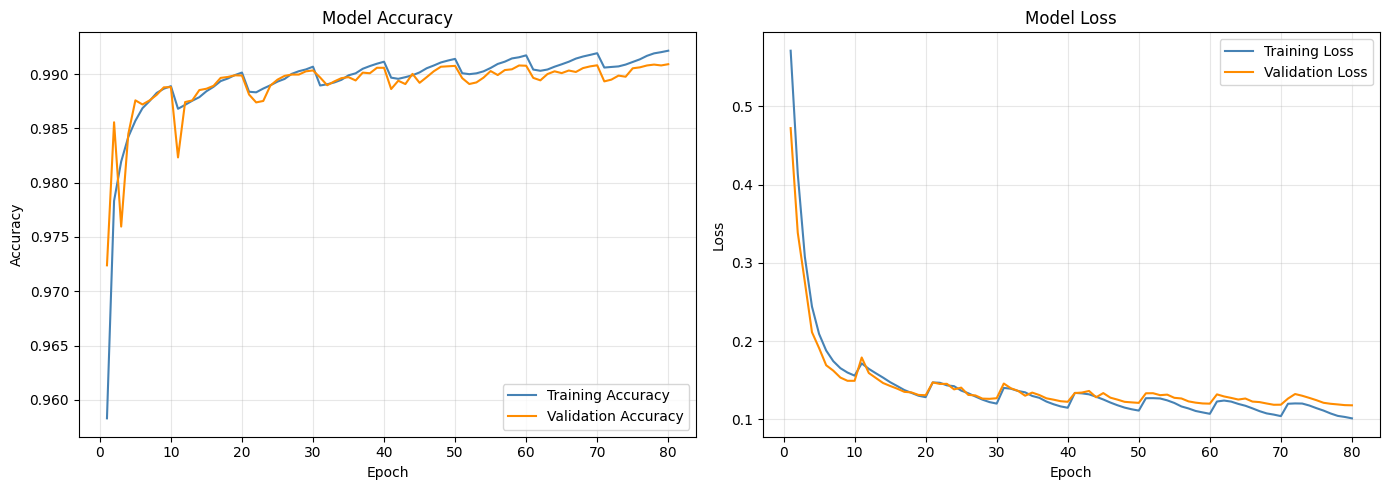

Plot saved to /kaggle/working/H2Former_history.png

--- Evaluating on Train Set ---
Total available train samples: 56788
Train: 4000 | Val: 1000

  TRAIN EVALUATION
  Loss       : 0.1186
  Dice       : 84.61%
  IoU        : 73.59%
  Pixel Acc  : 99.10%
  Accuracy   : 99.10%
  Precision  : 85.11%
  Recall     : 84.38%
  Specificity: 99.55%

--- Evaluating on Validation Set ---
Total available train samples: 56788
Train: 4000 | Val: 1000

  VALIDATION EVALUATION
  Loss       : 0.1140
  Dice       : 85.14%
  IoU        : 74.35%
  Pixel Acc  : 99.12%
  Accuracy   : 99.12%
  Precision  : 86.04%
  Recall     : 84.53%
  Specificity: 99.57%

--- Evaluating on Test Set ---
Total available test samples: 10364
Using test samples: 1000

  TEST EVALUATION
  Loss       : 0.1183
  Dice       : 84.78%
  IoU        : 73.78%
  Pixel Acc  : 99.08%
  Accuracy   : 99.08%
  Precision  : 86.96%
  Recall     : 82.99%
  Specificity: 99.60%

[FINAL RESULT] H2Former → Val Dice: 84.54% | Test IoU: 73.78%


In [3]:
import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch", "einops", "-q"], check=True)

import os, glob, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

BASE_PATH     = "/kaggle/input/datasets/ahmadnafeestihami/brats2021-2d-slices"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MSK_DIR = os.path.join(BASE_PATH, "train/masks")
TEST_IMG_DIR  = os.path.join(BASE_PATH, "test/images")
TEST_MSK_DIR  = os.path.join(BASE_PATH, "test/masks")

N_TRAIN = 4000
N_VAL   = 1000
N_TEST  = 1000

CFG = dict(
    img_size     = 256,
    batch_size   = 8,
    lr           = 1e-4,
    weight_decay = 1e-5,
    epochs       = 80,
    patience     = 10,
    device       = "cuda" if torch.cuda.is_available() else "cpu",
)
print(f"Device : {CFG['device']}")
print(f"PyTorch: {torch.__version__}")


class BraTSDataset(Dataset):
    def __init__(self, img_paths, mask_paths, img_size=256, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.img_size   = img_size
        self.augment    = augment

    def __len__(self):
        return len(self.img_paths)

    def _load(self, path, gray=False):
        img = Image.open(path).convert("L" if gray else "RGB")
        return img.resize((self.img_size, self.img_size), Image.BILINEAR)

    def __getitem__(self, idx):
        img  = self._load(self.img_paths[idx])
        mask = self._load(self.mask_paths[idx], gray=True)
        if self.augment:
            if random.random() > 0.5: img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() > 0.5: img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            if angle:
                img  = TF.rotate(img,  angle)
                mask = TF.rotate(mask, angle)
            img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
            img = TF.adjust_contrast(img,   random.uniform(0.8, 1.2))
        img  = TF.to_tensor(img)
        img  = TF.normalize(img, [0.5]*3, [0.5]*3)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask


def get_loaders():
    all_img_paths  = sorted(glob.glob(os.path.join(TRAIN_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TRAIN_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No images found at {TRAIN_IMG_DIR}"
    assert len(all_img_paths) == len(all_mask_paths), "Image/mask count mismatch!"
    print(f"Total available train samples: {len(all_img_paths)}")
    idx      = list(range(len(all_img_paths)))
    random.shuffle(idx)
    selected = idx[:N_TRAIN + N_VAL]
    t_idx    = selected[:N_TRAIN]
    v_idx    = selected[N_TRAIN:]
    train_ds = BraTSDataset([all_img_paths[i] for i in t_idx],
                             [all_mask_paths[i] for i in t_idx],
                             CFG["img_size"], augment=True)
    val_ds   = BraTSDataset([all_img_paths[i] for i in v_idx],
                             [all_mask_paths[i] for i in v_idx],
                             CFG["img_size"], augment=False)
    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True,  num_workers=4, pin_memory=True,
                              persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=4, pin_memory=True,
                              persistent_workers=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
    return train_loader, val_loader


def get_test_loader():
    all_img_paths  = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TEST_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No test images found at {TEST_IMG_DIR}"
    print(f"Total available test samples: {len(all_img_paths)}")
    idx          = list(range(len(all_img_paths)))
    random.shuffle(idx)
    selected_idx = idx[:N_TEST]
    test_ds = BraTSDataset([all_img_paths[i] for i in selected_idx],
                            [all_mask_paths[i] for i in selected_idx],
                            CFG["img_size"], augment=False)
    print(f"Using test samples: {len(test_ds)}")
    return DataLoader(test_ds, batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=4, pin_memory=True,
                      persistent_workers=True)


class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2, 3))
        dice  = 1 - (2*inter + self.smooth) / (
                    prob.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return 0.5 * dice.mean() + 0.5 * bce


def compute_metrics(logits, masks, thresh=0.5):
    preds = (torch.sigmoid(logits) > thresh).float()
    inter = (preds * masks).sum()
    dice  = (2*inter + 1) / (preds.sum() + masks.sum() + 1)
    iou   = (inter + 1)   / (preds.sum() + masks.sum() - inter + 1)
    acc   = (preds == masks).float().mean()
    tp    = ((preds==1)&(masks==1)).sum().float()
    tn    = ((preds==0)&(masks==0)).sum().float()
    fp    = ((preds==1)&(masks==0)).sum().float()
    fn    = ((preds==0)&(masks==1)).sum().float()
    prec  = tp / (tp + fp + 1e-7)
    rec   = tp / (tp + fn + 1e-7)
    spec  = tn / (tn + fp + 1e-7)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    return dice.item(), iou.item(), acc.item(), prec.item(), rec.item(), spec.item(), pixel_acc.item()


def evaluate_split(model, loader, device, split_name):
    model.eval()
    criterion = DiceBCELoss()
    total_loss = 0.0
    v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                out = model(imgs)
                if out.shape[-2:] != masks.shape[-2:]:
                    out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                total_loss += criterion(out, masks).item()
            d, i, a, p, r, s, px = compute_metrics(out, masks)
            v_dice += d; v_iou += i; v_acc += a
            v_prec += p; v_rec += r; v_spec += s; v_pix += px
    n = len(loader)
    print(f"\n{'='*60}")
    print(f"  {split_name} EVALUATION")
    print(f"{'='*60}")
    print(f"  Loss       : {total_loss/n:.4f}")
    print(f"  Dice       : {v_dice/n*100:.2f}%")
    print(f"  IoU        : {v_iou/n*100:.2f}%")
    print(f"  Pixel Acc  : {v_pix/n*100:.2f}%")
    print(f"  Accuracy   : {v_acc/n*100:.2f}%")
    print(f"  Precision  : {v_prec/n*100:.2f}%")
    print(f"  Recall     : {v_rec/n*100:.2f}%")
    print(f"  Specificity: {v_spec/n*100:.2f}%")
    print(f"{'='*60}")
    return v_dice/n, v_iou/n


def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history["train_acc"], color='steelblue',  linewidth=1.5, label="Training Accuracy")
    axes[0].plot(epochs, history["val_acc"],   color='darkorange', linewidth=1.5, label="Validation Accuracy")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["train_loss"], color='steelblue',  linewidth=1.5, label="Training Loss")
    axes[1].plot(epochs, history["val_loss"],   color='darkorange', linewidth=1.5, label="Validation Loss")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{model_name}_history.png", dpi=150)
    plt.show()
    print(f"Plot saved to /kaggle/working/{model_name}_history.png")


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ReverseSEBlock(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        mid = max(ch // reduction, 8)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, ch),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(x).view(x.shape[0], x.shape[1], 1, 1)


class HybridEncoder(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv_branch = nn.Sequential(ConvBNReLU(in_ch, out_ch), ReverseSEBlock(out_ch))
        self.dw_branch   = nn.Sequential(DepthwiseSeparableConv(in_ch, out_ch), ReverseSEBlock(out_ch))
        self.fuse        = nn.Sequential(
            nn.Conv2d(out_ch * 2, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.fuse(torch.cat([self.conv_branch(x), self.dw_branch(x)], dim=1))


class EfficientAttention(nn.Module):
    def __init__(self, ch, num_heads=8, dropout=0.1, pool_size=8):
        super().__init__()
        self.num_heads = num_heads
        self.scale     = (ch // num_heads) ** -0.5
        self.pool_size = pool_size
        self.norm      = nn.LayerNorm(ch)
        self.q_proj    = nn.Linear(ch, ch, bias=False)
        self.kv_proj   = nn.Linear(ch, ch * 2, bias=False)
        self.out_proj  = nn.Linear(ch, ch, bias=False)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)
        self.norm2     = nn.LayerNorm(ch)
        self.ffn       = nn.Sequential(
            nn.Linear(ch, ch * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ch * 2, ch), nn.Dropout(dropout),
        )

    def forward(self, x):
        B, C, H, W   = x.shape
        t            = x.flatten(2).transpose(1, 2)
        n            = self.norm(t)
        q            = self.q_proj(n)
        x_pooled     = F.adaptive_avg_pool2d(x, self.pool_size)
        kv_tok       = x_pooled.flatten(2).transpose(1, 2)
        kv           = self.kv_proj(kv_tok)
        k, v         = kv.chunk(2, dim=-1)
        q  = q.reshape(B, H*W,              self.num_heads, C // self.num_heads).transpose(1, 2)
        k  = k.reshape(B, self.pool_size**2, self.num_heads, C // self.num_heads).transpose(1, 2)
        v  = v.reshape(B, self.pool_size**2, self.num_heads, C // self.num_heads).transpose(1, 2)
        attn = self.attn_drop((q @ k.transpose(-2, -1) * self.scale).softmax(dim=-1))
        out  = (attn @ v).transpose(1, 2).reshape(B, H*W, C)
        t    = t + self.proj_drop(self.out_proj(out))
        t    = t + self.ffn(self.norm2(t))
        return t.transpose(1, 2).reshape(B, C, H, W)


class SkipFusionModule(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.channels = channels
        ref_ch        = channels[-1]
        self.down_projs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, ref_ch, 1, bias=False),
                nn.BatchNorm2d(ref_ch),
                nn.ReLU(inplace=True),
            ) for ch in channels
        ])
        total         = ref_ch * len(channels)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = total,
            nhead           = max(1, total // 64),
            dim_feedforward = total * 2,
            dropout         = dropout,
            activation      = 'gelu',
            batch_first     = True,
            norm_first      = True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers           = 1,
            enable_nested_tensor = False,
        )
        self.norm_in    = nn.LayerNorm(total)
        self.norm_out   = nn.LayerNorm(total)
        self.back_projs = nn.ModuleList([nn.Linear(ref_ch, ch) for ch in channels])
        self.out_norms  = nn.ModuleList([nn.LayerNorm(ch) for ch in channels])
        self.ref_ch     = ref_ch

    def forward(self, feature_list):
        B        = feature_list[0].shape[0]
        spatials = [(f.shape[2], f.shape[3]) for f in feature_list]
        ref_H, ref_W = spatials[-1]
        pooled = []
        for feat, proj in zip(feature_list, self.down_projs):
            p = proj(feat)
            if (p.shape[2], p.shape[3]) != (ref_H, ref_W):
                p = F.interpolate(p, size=(ref_H, ref_W), mode='bilinear', align_corners=False)
            pooled.append(p.flatten(2).transpose(1, 2))
        tokens  = self.norm_out(self.transformer(self.norm_in(torch.cat(pooled, dim=-1))))
        outputs = []
        for i, (chunk, proj, norm) in enumerate(zip(
                torch.chunk(tokens, len(self.channels), dim=-1),
                self.back_projs, self.out_norms)):
            H, W = spatials[i]
            t    = norm(proj(chunk)).transpose(1, 2).reshape(B, self.channels[i], ref_H, ref_W)
            if (ref_H, ref_W) != (H, W):
                t = F.interpolate(t, size=(H, W), mode='bilinear', align_corners=False)
            outputs.append(t)
        return outputs


class H2Former(nn.Module):
    def __init__(self, in_ch=3, num_classes=1, base=64):
        super().__init__()
        f = [base, base*2, base*4, base*8, base*16]

        self.enc1 = HybridEncoder(in_ch, f[0])
        self.enc2 = HybridEncoder(f[0],  f[1])
        self.enc3 = HybridEncoder(f[1],  f[2])
        self.enc4 = HybridEncoder(f[2],  f[3])
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            ConvBNReLU(f[3], f[4]),
            EfficientAttention(f[4], num_heads=8, dropout=0.1, pool_size=8),
        )

        self.sfm = SkipFusionModule(
            channels = [f[1], f[2], f[3]],
            dropout  = 0.1,
        )

        self.up4  = nn.ConvTranspose2d(f[4], f[3], 2, stride=2)
        self.dec4 = ConvBNReLU(f[3]*2, f[3])
        self.up3  = nn.ConvTranspose2d(f[3], f[2], 2, stride=2)
        self.dec3 = ConvBNReLU(f[2]*2, f[2])
        self.up2  = nn.ConvTranspose2d(f[2], f[1], 2, stride=2)
        self.dec2 = ConvBNReLU(f[1]*2, f[1])
        self.up1  = nn.ConvTranspose2d(f[1], f[0], 2, stride=2)
        self.dec1 = ConvBNReLU(f[0]*2, f[0])

        self.dropout = nn.Dropout2d(0.3)
        self.head    = nn.Conv2d(f[0], num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        e2t, e3t, e4t = self.sfm([e2, e3, e4])

        d4 = self.dec4(torch.cat([self.up4(b),  e4t], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3t], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2t], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1],  1))
        return self.head(self.dropout(d1))


def train_model(model, model_name):
    device = CFG["device"]
    model  = model.to(device)
    train_loader, val_loader = get_loaders()
    criterion = DiceBCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)
    scaler    = torch.cuda.amp.GradScaler()
    best_dice, no_improve = 0.0, 0
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  Model  : {model_name}")
    print(f"  Params : {n_params/1e6:.2f}M")
    print(f"  Device : {device}")
    print(f"{'='*60}")
    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        t_loss = t_acc = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                out = model(imgs)
                if out.shape[-2:] != masks.shape[-2:]:
                    out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                loss = criterion(out, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()
            with torch.no_grad():
                _, _, a, _, _, _, _ = compute_metrics(out, masks)
            t_acc += a
        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)
        model.eval()
        v_loss = v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
                with torch.cuda.amp.autocast():
                    out = model(imgs)
                    if out.shape[-2:] != masks.shape[-2:]:
                        out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                    v_loss += criterion(out, masks).item()
                d, i, a, p, r, s, px = compute_metrics(out, masks)
                v_dice += d; v_iou += i; v_acc += a
                v_prec += p; v_rec += r; v_spec += s; v_pix += px
        n = len(val_loader)
        v_loss /= n; v_dice /= n; v_iou /= n; v_acc /= n
        v_prec /= n; v_rec /= n; v_spec /= n; v_pix /= n
        scheduler.step()
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:03d} | Loss:{t_loss:.4f} | "
                  f"Dice:{v_dice:.4f} | IoU:{v_iou:.4f} | "
                  f"PixAcc:{v_pix:.4f} | Acc:{v_acc:.4f} | "
                  f"Prec:{v_prec:.4f} | Rec:{v_rec:.4f} | Spec:{v_spec:.4f}")
        if v_dice > best_dice:
            best_dice    = v_dice
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= CFG["patience"]:
                print(f"  Early stop at epoch {epoch}.")
                break
    model.load_state_dict(best_weights)
    print(f"\n{'='*60}")
    print(f"  {model_name} TRAINING COMPLETE")
    print(f"  Best Val Dice : {best_dice*100:.2f}%")
    print(f"{'='*60}")
    plot_history(history, model_name)
    print("\n--- Evaluating on Train Set ---")
    train_loader_eval, _ = get_loaders()
    evaluate_split(model, train_loader_eval, device, "TRAIN")
    print("\n--- Evaluating on Validation Set ---")
    _, val_loader_eval = get_loaders()
    evaluate_split(model, val_loader_eval, device, "VALIDATION")
    print("\n--- Evaluating on Test Set ---")
    test_loader = get_test_loader()
    test_dice, test_iou = evaluate_split(model, test_loader, device, "TEST")
    return model, history, best_dice, test_iou


torch.cuda.empty_cache()
model_h2former = H2Former(in_ch=3, num_classes=1, base=64)
model_h2former, history_h2former, dice_h2former, iou_h2former = train_model(model_h2former, "H2Former")
print(f"\n[FINAL RESULT] H2Former → Val Dice: {dice_h2former*100:.2f}% | Test IoU: {iou_h2former*100:.2f}%")+333333333333333333333333.